# The ReAct (Reason + Act) Agent Framework

The **ReAct** (Reason and Act) framework combines reasoning capabilities with action execution to enable LLMs to solve complex problems in an iterative, step-by-step manner.

```
                   +-------------------+
                   |   User Prompt     |
                   +---------+---------+
                             |
                             v
               +-------------+-------------+
               |  LLM Node (Reasoning)     | <---------+
               +-------------+-------------+           |
                             |                         |
               Does LLM need to run a tool?            |
                             |                         |
              +--------------+--------------+          |
              |                             |          |
           (Yes)                          (No)         |
              |                             |          |
              v                             v          |
      +-------+-------+             +-------+-------+  |
      |   Tool Node   |             |   End / User  |  |
      |   (Action)    |             |   Response    |  |
      +-------+-------+             +---------------+  |
              |                                        |
              v                                        |
      Add Tool Result                                  |
     to Messages State --------------------------------+
```

## How ReAct Works:
1. **Thought (Reasoning):** The LLM thinks about the problem and decides if it needs external information or computation.
2. **Action (Acting):** If yes, the LLM generates a tool call (with specific input arguments).
3. **Observation:** The environment executes the tool and returns the output (Observation) back into the state/history.
4. **Iterate:** The LLM receives the tool's output, reasons about it, and either calls another tool or outputs the final answer.

## Key Benefits of ReAct in LangGraph:
- **Traceability:** You can see exactly what the model thought before calling a tool and what the output was.
- **Robustness:** If a tool fails or returns unexpected results, the LLM can see the error observation and try a different query or tool in the next cycle.
- **Dynamic Behavior:** The LLM determines its next steps dynamically based on real-time observations, rather than following a rigid hard-coded pipeline.

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langchain_community.tools import DuckDuckGoSearchRun
from langchain.tools import  tool

@tool()
def multiply(num1:int, num2:int):
    """
        Multiply 2 numbers
        num1: first number
        num2: second number
    """
    return num1 * num2

search_tool = DuckDuckGoSearchRun(max_result=2)

tools = [search_tool, multiply ]


/var/folders/13/z7gxlg_d1g152wq8vm7gz0xr0000gn/T/ipykernel_46002/631375114.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun


In [3]:

#test search tool working

search_tool.invoke("what is langchain")

"11 Jun 2026 ... LangChain is an open-source framework that simplifies building applications using large language models. It helps developers connect LLMs with external data, ... 26 Aug 2025 ... LangChain is a framework for building AI applications that are connected with other data sources and tools. It provides modules to help you manage things like ... 19 Aug 2025 ... Try LangChain Hands-on Labs for Free: https://kode.wiki/462mo31 Building a company chatbot that remembers conversations, accesses your knowledge base, ... 16 Oct 2025 ... LangChain is an open source framework with pre-built agent architectures and as integrations to models, tools, and databases to start building agents quickly. 19 Aug 2025 ... At its core, LangChain is a framework that handles all the tedious, repetitive stuff you'd otherwise have to code yourself when working with Large Language ..."

In [4]:
from langchain_groq import ChatGroq

llm = ChatGroq(model = "llama-3.1-8b-instant")

llm_with_tool = llm.bind_tools(tools)

In [5]:
from pydantic import BaseModel, Field
from typing import  Annotated
from langgraph.graph.message import add_messages

class ChatBotState(BaseModel):
    messages: Annotated[list, add_messages]
    count: int = Field( description="count of messages")

In [6]:

# Create node

def chatbot_llm(state:ChatBotState):
    result = llm_with_tool.invoke(state.messages)
    return { "messages": result, "count": state.count + 1 }

In [7]:
from langgraph.graph import StateGraph

graph_builder = StateGraph(ChatBotState)

# Tool Node here ReAct will not work

In [8]:
from langgraph.graph import START, END
from langgraph.prebuilt import ToolNode, tools_condition

graph_builder.add_node("chatbot_llm", chatbot_llm)
graph_builder.add_node("tools", ToolNode(tools))

graph_builder.add_edge(START, "chatbot_llm")


graph_builder.add_conditional_edges("chatbot_llm", tools_condition)
#pass tools result again to llm insted END
graph_builder.add_edge("tools", "chatbot_llm" )


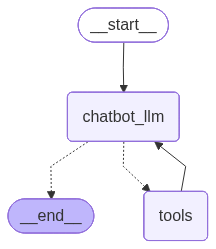

In [9]:
graph = graph_builder.compile()

graph

In [10]:

response = graph.invoke({"messages": "What is today's share price of ITC just give number", "count": 0})

response

{'messages': [HumanMessage(content="What is today's share price of ITC just give number", additional_kwargs={}, response_metadata={}, id='878502e8-7b54-485a-b52f-afc9d2c1de51'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'yv1jn5070', 'function': {'arguments': '{"query":"ITC share price today"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 359, 'total_tokens': 380, 'completion_time': 0.018965248, 'completion_tokens_details': None, 'prompt_time': 0.01980147, 'prompt_tokens_details': None, 'queue_time': 0.15900467, 'total_time': 0.038766718}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ee55f-8af2-7b30-9465-f1bd182d05a6-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'ITC share price today'}, 'id': 'yv1jn5070', 'type'

In [11]:
response["messages"][-1].content

'The current share price of ITC is ₹292.'

In [12]:
response["messages"][-1].pretty_print()

================================== Ai Message ==================================

The current share price of ITC is ₹292.


In [16]:
response = graph.invoke({"messages": "What is today's share price of ITC just give number and what is 2 multiply by 5", "count": 0})
# here only one tool call will happen
response["messages"][-1].pretty_print()

================================== Ai Message ==================================

It appears that the ITC share price is not available in real-time, but based on the past data we can see that it has fluctuated between Rs 295.7 and Rs 512.85. As for the second question, the result of 2 multiplied by 5 is 10.
